# Concatenation of Pointclouds into one World Frame Tutorial


### Instead of visualizing only one point cloud at a time, we can simply aggregate all point cloud data frames into a single large one for visualization.

#### Load a sequence and its LiDAR point clouds

In [1]:
import pandaset

dataset = pandaset.DataSet('/media/bvb/SSD-1/panda/pandaset-devkit-master/data/pandaset')
seq002 = dataset['002']
seq002.load_lidar()

#### Use pandas concat method to concatenate all frames in selected slice

In [2]:
import pandas as pd

selected_data = seq002.lidar[::5]  # Take every 5th frame from sequence
_ = list(map(lambda xy: xy[1].insert(3,'f', xy[0]), enumerate(selected_data)))# Add column 'f' to each data frame in order

selected_data = pd.concat(selected_data)  # Concatenate in order

#### For better visualization we can scale the values in column `f` to `[0,1]` so it can be used for better point cloud colors.

In [3]:
import matplotlib.pyplot as plt

selected_data['f'] = (selected_data['f'] - selected_data['f'].min()) + 0.1*(selected_data['f'].max() - selected_data['f'].min())  # Add 10% of color range as base color (otherwise frame0 has white points)
selected_data['f'] /= selected_data['f'].max()

#### Now  we can use the concatenated point clouds with open3d visualizer

In [4]:
import open3d as o3d
import numpy as np

o3d_pc = o3d.geometry.PointCloud()
o3d_pc.points = o3d.utility.Vector3dVector(selected_data.to_numpy()[:, :3])
blue_colors = np.zeros((selected_data['f'].size,3))
blue_colors[:,2] = selected_data['f'].transpose()
o3d_pc.colors = o3d.utility.Vector3dVector(blue_colors)
o3d.visualization.draw_geometries([o3d_pc], window_name="concat frame")


Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


In [4]:
import pandas as pd
import gzip
import pickle

# Example: load one LiDAR frame
with gzip.open("/media/bvb/SSD-1/panda/pandaset-devkit-master/data/pandaset/002/lidar/00.pkl.gz", "rb") as f:
    lidar_frame = pickle.load(f)

print(lidar_frame.head())


                x           y         z     i             t  d
index                                                         
0      -75.131138  -79.331690  3.511804   7.0  1.557540e+09  0
1     -112.588306 -118.666002  1.423499  31.0  1.557540e+09  0
2      -42.085902  -44.384891  0.593491   7.0  1.557540e+09  0
3      -27.329435  -28.795053 -0.403781   0.0  1.557540e+09  0
4       -6.196208   -6.621082  1.130009   3.0  1.557540e+09  0


In [5]:
import glob
import os

# Path to LiDAR frames of one sequence
lidar_path = "/media/bvb/SSD-1/panda/pandaset-devkit-master/data/pandaset/002/lidar/"
files = sorted(glob.glob(os.path.join(lidar_path, "*.pkl.gz")))

# Load first 5 frames as example
frames = []
for i, file in enumerate(files[:5]):
    with gzip.open(file, "rb") as f:
        df = pickle.load(f)
        df["f"] = i   # frame index
        frames.append(df)

# Concatenate
all_points = pd.concat(frames)
print(all_points.head())


                x           y         z     i             t  d  f
index                                                            
0      -75.131138  -79.331690  3.511804   7.0  1.557540e+09  0  0
1     -112.588306 -118.666002  1.423499  31.0  1.557540e+09  0  0
2      -42.085902  -44.384891  0.593491   7.0  1.557540e+09  0  0
3      -27.329435  -28.795053 -0.403781   0.0  1.557540e+09  0  0
4       -6.196208   -6.621082  1.130009   3.0  1.557540e+09  0  0


In [6]:
import numpy as np
from mayavi import mlab

# Normalize frame index for coloring
all_points["f"] = (all_points["f"] - all_points["f"].min()) / (all_points["f"].max() - all_points["f"].min())

# Convert to numpy
pts = all_points[["x", "y", "z"]].to_numpy()
colors = all_points["f"].to_numpy()

# Plot
mlab.figure("Concatenated LiDAR", bgcolor=(0,0,0), size=(1000,800))
mlab.points3d(pts[:,0], pts[:,1], pts[:,2],
              colors,
              mode="point", colormap="spectral")

mlab.show()


In [7]:
# Load cuboids file for the sequence
cuboids_file = "/media/bvb/SSD-1/panda/pandaset-devkit-master/data/pandaset/002/annotations/cuboids/00.pkl.gz"

with gzip.open(cuboids_file, "rb") as f:
    cuboids_df = pickle.load(f)

print(cuboids_df.head())


                                   uuid label       yaw  stationary  \
0  e83d78e4-5b11-4ad5-ac71-917b5cd19c94   Car -0.840044        True   
1  b113987c-bde4-43b3-b7f2-8a9a80318ae2   Car  2.352911        True   
2  47a397d6-9f2f-4e3b-9316-00ad60320f6d   Car  2.387817        True   
3  92b61b3d-8f2f-4205-921b-fdc047ab86e2   Car -0.787685        True   
4  895e6a77-1506-4f55-a977-baf5f86840e1   Car  2.405271        True   

   camera_used  position.x  position.y  position.z  dimensions.x  \
0            2       7.361       2.630       0.487         1.888   
1            5     -12.659       6.353       0.361         1.837   
2            4     -41.504     -22.578       0.393         1.930   
3            1      11.697       7.260       0.548         2.099   
4            4     -51.568     -32.920       0.486         1.967   

   dimensions.y  dimensions.z attributes.object_motion cuboids.sibling_id  \
0         4.747         1.761                   Parked                  -   
1         

In [8]:
import numpy as np

def get_cuboid_corners(cuboid):
    x, y, z = cuboid["position.x"], cuboid["position.y"], cuboid["position.z"]
    dx, dy, dz = cuboid["dimensions.x"], cuboid["dimensions.y"], cuboid["dimensions.z"]
    yaw = cuboid["yaw"]

    # 8 corner offsets
    corners = np.array([
        [ dx/2,  dy/2, -dz/2],
        [-dx/2,  dy/2, -dz/2],
        [-dx/2, -dy/2, -dz/2],
        [ dx/2, -dy/2, -dz/2],
        [ dx/2,  dy/2,  dz/2],
        [-dx/2,  dy/2,  dz/2],
        [-dx/2, -dy/2,  dz/2],
        [ dx/2, -dy/2,  dz/2],
    ])

    # Rotation (yaw around z-axis)
    rot = np.array([
        [np.cos(yaw), -np.sin(yaw), 0],
        [np.sin(yaw),  np.cos(yaw), 0],
        [0, 0, 1]
    ])
    corners = corners @ rot.T
    corners += np.array([x, y, z])
    return corners


In [9]:
from mayavi import mlab

def draw_cuboid(corners, color=(1,0,0)):
    edges = [
        (0,1),(1,2),(2,3),(3,0),  # bottom
        (4,5),(5,6),(6,7),(7,4),  # top
        (0,4),(1,5),(2,6),(3,7)   # verticals
    ]
    for i,j in edges:
        mlab.plot3d(
            [corners[i,0], corners[j,0]],
            [corners[i,1], corners[j,1]],
            [corners[i,2], corners[j,2]],
            color=color, tube_radius=None, line_width=1.0
        )


In [10]:
mlab.figure("LiDAR + Cuboids", bgcolor=(0,0,0), size=(1000,800))

# Draw LiDAR points
mlab.points3d(pts[:,0], pts[:,1], pts[:,2],
              colors, mode="point", colormap="spectral")

# Draw cuboids
for _, cuboid in cuboids_df.iterrows():
    corners = get_cuboid_corners(cuboid)
    draw_cuboid(corners, color=(1,0,0))  # red boxes

mlab.show()


: 

In [6]:
from pandaset import DataSet
import numpy as np
from mayavi import mlab

# -----------------------------
# Load dataset and sequence
# -----------------------------
dataset = DataSet("/media/bvb/SSD-1/panda/pandaset-devkit-master/data/pandaset")

seq = dataset["002"]    
seq.load_lidar()
seq.load_cuboids()
seq.load()   # <-- this loads everything, including cameras

# -----------------------------
# Access cameras
# -----------------------------
print("Available cameras:", seq.camera.keys())
camera = seq.camera["front_camera"]

# -----------------------------
# Get LiDAR + cuboids
# -----------------------------
frame_idx = 0
lidar_df = seq.lidar[frame_idx]
cuboids_df = seq.cuboids[frame_idx]

# Quick filter: keep only front-ish lidar points
lidar_front = lidar_df[
    (lidar_df["x"] > 0) & 
    (np.abs(lidar_df["y"]) < 40) &
    (lidar_df["x"] < 80)
]

# -----------------------------
# Plot in Mayavi
# -----------------------------
mlab.figure(bgcolor=(0, 0, 0), size=(1000, 800))
mlab.points3d(lidar_front["x"], lidar_front["y"], lidar_front["z"],
              lidar_front["z"], mode="point", colormap="spectral")

def draw_cuboid(cuboid, color=(1,0,0)):
    x, y, z = cuboid["position.x"], cuboid["position.y"], cuboid["position.z"]
    dx, dy, dz = cuboid["dimensions.x"], cuboid["dimensions.y"], cuboid["dimensions.z"]
    yaw = cuboid["yaw"]

    corners = np.array([
        [ dx/2,  dy/2, -dz/2],
        [-dx/2,  dy/2, -dz/2],
        [-dx/2, -dy/2, -dz/2],
        [ dx/2, -dy/2, -dz/2],
        [ dx/2,  dy/2,  dz/2],
        [-dx/2,  dy/2,  dz/2],
        [-dx/2, -dy/2,  dz/2],
        [ dx/2, -dy/2,  dz/2],
    ])
    rot = np.array([
        [np.cos(yaw), -np.sin(yaw), 0],
        [np.sin(yaw),  np.cos(yaw), 0],
        [0, 0, 1]
    ])
    corners = corners @ rot.T
    corners += np.array([x, y, z])

    edges = [(0,1),(1,2),(2,3),(3,0),
             (4,5),(5,6),(6,7),(7,4),
             (0,4),(1,5),(2,6),(3,7)]
    for i,j in edges:
        mlab.plot3d([corners[i,0], corners[j,0]],
                    [corners[i,1], corners[j,1]],
                    [corners[i,2], corners[j,2]],
                    color=color, tube_radius=None, line_width=1.0)

for _, cub in cuboids_df.iterrows():
    draw_cuboid(cub, color=(1,0,0))

mlab.show()


Available cameras: dict_keys(['left_camera', 'back_camera', 'right_camera', 'front_left_camera', 'front_camera', 'front_right_camera'])


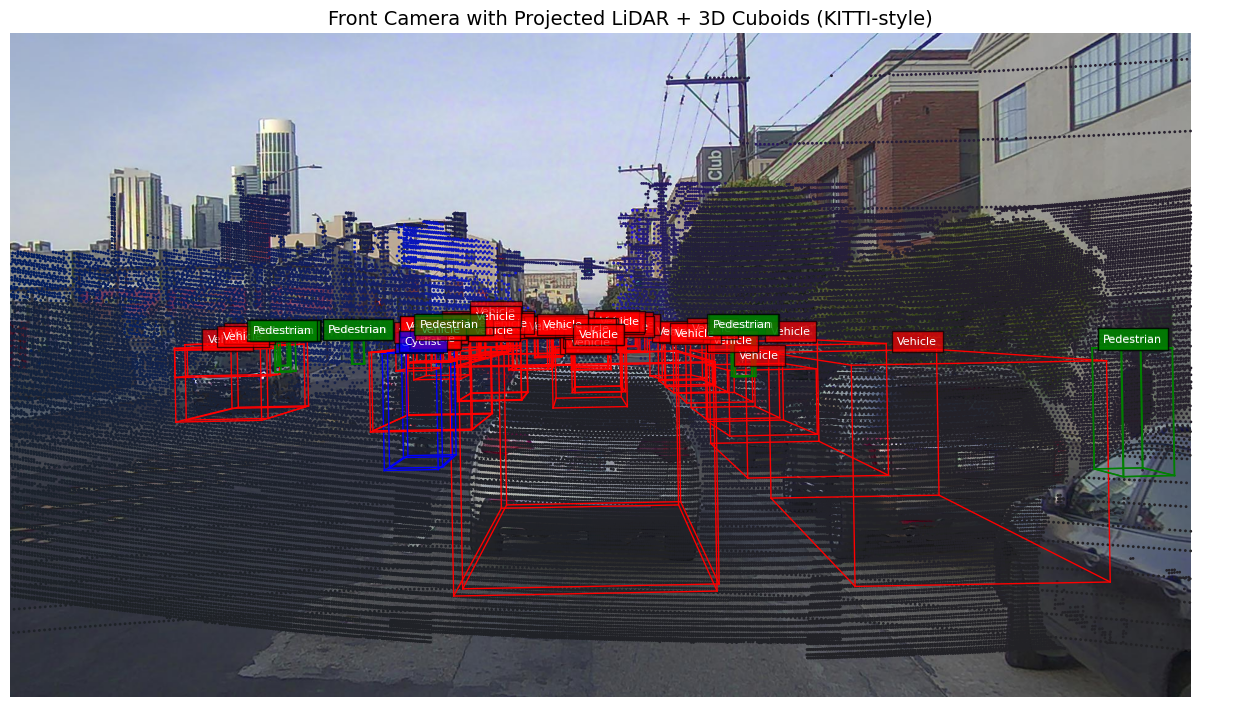

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from pandaset import DataSet, geometry

# ======================================================
# Load Pandaset sequence
# ======================================================
# ⚠️ Change this path to your Pandaset folder
dataset = DataSet("/media/bvb/SSD-1/panda/pandaset-devkit-master/data/pandaset")

# Pick a sequence (from your available list e.g., '002')
seq = dataset["002"]
seq.load_lidar()
seq.load_cuboids()
front_cam = seq.camera["front_camera"]
front_cam.load()

# ======================================================
# Pick a frame
# ======================================================
frame_idx = 0
lidar_points = seq.lidar[frame_idx][["x", "y", "z"]].to_numpy()  # (N,3)
cuboids = seq.cuboids[frame_idx]                                 # bounding boxes DataFrame
img = np.array(front_cam[frame_idx])                             # front camera image

# ======================================================
# Project LiDAR to camera
# ======================================================
# NOTE: filter_outliers=True already drops invalid points
projected, depths, mask = geometry.projection(
    lidar_points,
    front_cam[frame_idx],         # camera image
    front_cam.poses[frame_idx],   # camera pose
    front_cam.intrinsics,         # intrinsics
    filter_outliers=True
)

# ======================================================
# Function: cuboid corners
# ======================================================
def get_cuboid_corners(cuboid):
    x, y, z = cuboid["position.x"], cuboid["position.y"], cuboid["position.z"]
    dx, dy, dz = cuboid["dimensions.x"], cuboid["dimensions.y"], cuboid["dimensions.z"]
    yaw = cuboid["yaw"]

    # 8 corner offsets
    corners = np.array([
        [ dx/2,  dy/2, -dz/2],
        [-dx/2,  dy/2, -dz/2],
        [-dx/2, -dy/2, -dz/2],
        [ dx/2, -dy/2, -dz/2],
        [ dx/2,  dy/2,  dz/2],
        [-dx/2,  dy/2,  dz/2],
        [-dx/2, -dy/2,  dz/2],
        [ dx/2, -dy/2,  dz/2],
    ])

    # Rotate around Z (yaw)
    R = np.array([
        [np.cos(yaw), -np.sin(yaw), 0],
        [np.sin(yaw),  np.cos(yaw), 0],
        [0, 0, 1]
    ])
    corners = corners @ R.T
    corners += np.array([x, y, z])
    return corners

# Map Pandaset labels to KITTI-style categories
def simplify_label(label):
    if "Car" in label or "Truck" in label or "Van" in label or "Bus" in label:
        return "Vehicle"
    elif "Pedestrian" in label:
        return "Pedestrian"
    elif "Cyclist" in label or "Bicycle" in label or "Motorcycle" in label:
        return "Cyclist"
    else:
        return None  # ignore others

# Colors per class
class_colors = {
    "Vehicle": "red",
    "Pedestrian": "green",
    "Cyclist": "blue"
}

# ======================================================
# Plot
# ======================================================
plt.figure(figsize=(16, 9))
plt.imshow(img)

# Normalize depth values into [0,1] for colormap
depths_normalized = (depths - depths.min()) / (depths.max() - depths.min())
plt.scatter(projected[:, 0], projected[:, 1], c=depths_normalized, cmap="jet", s=1)

# Draw cuboids
edges = [
    (0,1),(1,2),(2,3),(3,0),  # bottom
    (4,5),(5,6),(6,7),(7,4),  # top
    (0,4),(1,5),(2,6),(3,7)   # verticals
]

for _, cub in cuboids.iterrows():
    category = simplify_label(cub["label"])
    if category is None:
        continue

    color = class_colors[category]
    corners = get_cuboid_corners(cub)

    # Project cuboid corners to 2D
    proj_corners, _, _ = geometry.projection(
        corners,
        front_cam[frame_idx],
        front_cam.poses[frame_idx],
        front_cam.intrinsics,
        filter_outliers=True
    )

    if proj_corners.shape[0] != 8:
        continue

    # Draw edges
    for i, j in edges:
        plt.plot([proj_corners[i,0], proj_corners[j,0]],
                 [proj_corners[i,1], proj_corners[j,1]],
                 color=color, linewidth=1)

    # Label text
    cx, cy = np.mean(proj_corners[:,0]), np.min(proj_corners[:,1]) - 5
    plt.text(cx, cy, category, color="white", fontsize=8,
             ha="center", va="bottom", bbox=dict(facecolor=color, alpha=0.7))

plt.axis("off")
plt.title("Front Camera with Projected LiDAR + 3D Cuboids (KITTI-style)", fontsize=14)
plt.show()


In [13]:
import numpy as np
from mayavi import mlab
from pandaset import DataSet

# ======================================================
# Load Pandaset
# ======================================================
dataset = DataSet("/media/bvb/SSD-1/panda/pandaset-devkit-master/data/pandaset")
seq = dataset["002"]
seq.load_lidar()
seq.load_cuboids()

# Pick a frame
frame_idx = 0
lidar_points = seq.lidar[frame_idx][["x", "y", "z"]].to_numpy()
cuboids = seq.cuboids[frame_idx]

# ======================================================
# Define cuboid corners
# ======================================================
def get_cuboid_corners(cuboid):
    x, y, z = cuboid["position.x"], cuboid["position.y"], cuboid["position.z"]
    dx, dy, dz = cuboid["dimensions.x"], cuboid["dimensions.y"], cuboid["dimensions.z"]
    yaw = cuboid["yaw"]

    # 8 corner offsets
    corners = np.array([
        [ dx/2,  dy/2, -dz/2],
        [-dx/2,  dy/2, -dz/2],
        [-dx/2, -dy/2, -dz/2],
        [ dx/2, -dy/2, -dz/2],
        [ dx/2,  dy/2,  dz/2],
        [-dx/2,  dy/2,  dz/2],
        [-dx/2, -dy/2,  dz/2],
        [ dx/2, -dy/2,  dz/2],
    ])

    # Rotation around z
    R = np.array([
        [np.cos(yaw), -np.sin(yaw), 0],
        [np.sin(yaw),  np.cos(yaw), 0],
        [0, 0, 1]
    ])
    corners = corners @ R.T
    corners += np.array([x, y, z])
    return corners

# ======================================================
# Simplify labels (KITTI style)
# ======================================================
def simplify_label(label):
    if "Car" in label or "Truck" in label or "Van" in label or "Bus" in label:
        return "Vehicle"
    elif "Pedestrian" in label:
        return "Pedestrian"
    elif "Cyclist" in label or "Bicycle" in label or "Motorcycle" in label:
        return "Cyclist"
    else:
        return None

class_colors = {
    "Vehicle": (1, 0, 0),   # red
    "Pedestrian": (0, 1, 0),# green
    "Cyclist": (0, 0, 1)    # blue
}

# ======================================================
# Mayavi visualization
# ======================================================
mlab.figure("LiDAR + 3D Cuboids", bgcolor=(0,0,0), size=(1280,720))

# Plot lidar points
mlab.points3d(
    lidar_points[:,0],
    lidar_points[:,1],
    lidar_points[:,2],
    mode="point",
    colormap="spectral",
    scale_factor=1.0,
)

# Draw cuboids
edges = [
    (0,1),(1,2),(2,3),(3,0),  # bottom
    (4,5),(5,6),(6,7),(7,4),  # top
    (0,4),(1,5),(2,6),(3,7)   # verticals
]

for _, cub in cuboids.iterrows():
    category = simplify_label(cub["label"])
    if category is None:
        continue
    color = class_colors[category]
    corners = get_cuboid_corners(cub)

    for i,j in edges:
        mlab.plot3d(
            [corners[i,0], corners[j,0]],
            [corners[i,1], corners[j,1]],
            [corners[i,2], corners[j,2]],
            color=color,
            tube_radius=None,
            line_width=1.0
        )

mlab.show()


In [3]:
import numpy as np
import mayavi.mlab as mlab
from pandaset import DataSet

# -----------------------------
# Load Pandaset sequence
# -----------------------------
dataset = DataSet("/media/bvb/SSD-1/panda/pandaset-devkit-master/data/pandaset")
seq = dataset["002"]
seq.load_lidar().load_cuboids()

# Pick a frame
frame_idx = 0
lidar_points = seq.lidar[frame_idx].to_numpy()[:, :3]   # (x,y,z)
cuboids = seq.cuboids[frame_idx]

# -----------------------------
# Filter to FRONT camera field of view
# -----------------------------
fov_mask = (lidar_points[:, 0] > 0) & (np.abs(lidar_points[:, 1]) < 25) & (lidar_points[:, 0] < 60)
lidar_points = lidar_points[fov_mask]

# -----------------------------
# Map classes
# -----------------------------
def map_class(name):
    name = name.lower()
    if "car" in name or "truck" in name or "bus" in name or "vehicle" in name:
        return "Vehicle"
    elif "pedestrian" in name:
        return "Pedestrian"
    elif "cyclist" in name or "bicycle" in name or "motorcycle" in name:
        return "Cyclist"
    else:
        return None

cuboids["mapped_label"] = cuboids["label"].apply(map_class)
cuboids = cuboids[cuboids["mapped_label"].notna()]

# -----------------------------
# Draw cuboid with Mayavi
# -----------------------------
def draw_cuboid(cuboid, color=(1,0,0)):
    # Read values from columns
    x = cuboid["position.x"]
    y = cuboid["position.y"]
    z = cuboid["position.z"]
    dx = cuboid["dimensions.x"]
    dy = cuboid["dimensions.y"]
    dz = cuboid["dimensions.z"]
    yaw = cuboid["yaw"]

    # Define local corners
    corners = np.array([
        [ dx/2,  dy/2, -dz/2],
        [ dx/2, -dy/2, -dz/2],
        [-dx/2, -dy/2, -dz/2],
        [-dx/2,  dy/2, -dz/2],
        [ dx/2,  dy/2,  dz/2],
        [ dx/2, -dy/2,  dz/2],
        [-dx/2, -dy/2,  dz/2],
        [-dx/2,  dy/2,  dz/2],
    ])

    # Rotation about Z
    R = np.array([
        [np.cos(yaw), -np.sin(yaw), 0],
        [np.sin(yaw),  np.cos(yaw), 0],
        [0, 0, 1]
    ])
    rotated = corners @ R.T
    corners = rotated + np.array([x, y, z])

    edges = [
        (0,1),(1,2),(2,3),(3,0),
        (4,5),(5,6),(6,7),(7,4),
        (0,4),(1,5),(2,6),(3,7)
    ]
    for i,j in edges:
        mlab.plot3d(
            [corners[i,0], corners[j,0]],
            [corners[i,1], corners[j,1]],
            [corners[i,2], corners[j,2]],
            color=color, tube_radius=None, line_width=1.0
        )

# -----------------------------
# Plot in Mayavi
# -----------------------------
mlab.figure(bgcolor=(0,0,0), size=(1600,1000))
mlab.points3d(lidar_points[:,0], lidar_points[:,1], lidar_points[:,2],
              mode="point", color=(1,1,1), scale_factor=0.05)

for _, cub in cuboids.iterrows():
    if cub["mapped_label"] == "Vehicle":
        draw_cuboid(cub, color=(1,0,0))  # red
    elif cub["mapped_label"] == "Pedestrian":
        draw_cuboid(cub, color=(0,1,0))  # green
    elif cub["mapped_label"] == "Cyclist":
        draw_cuboid(cub, color=(0,0,1))  # blue

mlab.view(azimuth=180, elevation=90, distance=60, focalpoint=(30,0,0))  # front view
mlab.show()


In [4]:
import numpy as np
import mayavi.mlab as mlab
from pandaset import DataSet, geometry

# -----------------------------
# Load dataset and sequence
# -----------------------------
dataset = DataSet("/media/bvb/SSD-1/panda/pandaset-devkit-master/data/pandaset")
seq = dataset["002"]     # pick sequence
seq.load_lidar().load_cuboids().load_camera()

# Access front camera
front_cam = seq.camera["front_camera"]

# Choose frame
frame_idx = 0
lidar_points = seq.lidar[frame_idx].values[:, :3]   # xyz
cuboids = seq.cuboids[frame_idx]
img = np.array(front_cam[frame_idx])               # front image
h, w, _ = img.shape
print("Front cam image shape:", img.shape)

# -----------------------------
# Project lidar to camera FOV
# -----------------------------
projected, depths, mask = geometry.projection(
    lidar_points=lidar_points,
    camera_data=front_cam[frame_idx],
    camera_pose=front_cam.poses[frame_idx],
    camera_intrinsics=front_cam.intrinsics,
    filter_outliers=True
)

lidar_front = lidar_points[mask]  # keep only visible points
print("Original points:", lidar_points.shape, "Front view points:", lidar_front.shape)

# -----------------------------
# Mayavi Visualization
# -----------------------------
mlab.figure("Front LiDAR + 3D Boxes", bgcolor=(0,0,0), size=(w,h))

# Draw front-view lidar points
mlab.points3d(lidar_front[:,0], lidar_front[:,1], lidar_front[:,2],
              mode="point", color=(1,1,1), scale_factor=1)

# Helper: draw cuboid
def draw_cuboid(cuboid, color=(1,0,0)):
    x, y, z = cuboid["position.x"], cuboid["position.y"], cuboid["position.z"]
    dx, dy, dz = cuboid["dimensions.x"], cuboid["dimensions.y"], cuboid["dimensions.z"]
    yaw = cuboid["yaw"]

    # 8 corners
    corners = np.array([
        [ dx/2,  dy/2, -dz/2],
        [-dx/2,  dy/2, -dz/2],
        [-dx/2, -dy/2, -dz/2],
        [ dx/2, -dy/2, -dz/2],
        [ dx/2,  dy/2,  dz/2],
        [-dx/2,  dy/2,  dz/2],
        [-dx/2, -dy/2,  dz/2],
        [ dx/2, -dy/2,  dz/2],
    ])
    # rotation
    R = np.array([
        [np.cos(yaw), -np.sin(yaw), 0],
        [np.sin(yaw),  np.cos(yaw), 0],
        [0, 0, 1]
    ])
    corners = corners @ R.T + np.array([x, y, z])

    edges = [(0,1),(1,2),(2,3),(3,0),
             (4,5),(5,6),(6,7),(7,4),
             (0,4),(1,5),(2,6),(3,7)]
    for i,j in edges:
        mlab.plot3d([corners[i,0], corners[j,0]],
                    [corners[i,1], corners[j,1]],
                    [corners[i,2], corners[j,2]],
                    color=color, tube_radius=None, line_width=1)

# -----------------------------
# Draw cuboids only if inside camera FOV
# -----------------------------
for _, cub in cuboids.iterrows():
    c = np.array([[cub["position.x"], cub["position.y"], cub["position.z"]]])
    _, _, inside = geometry.projection(
        lidar_points=c,
        camera_data=front_cam[frame_idx],
        camera_pose=front_cam.poses[frame_idx],
        camera_intrinsics=front_cam.intrinsics,
        filter_outliers=True
    )
    
    if inside.size > 0 and inside[0]:
        if cub["label"] == "Vehicle":
            draw_cuboid(cub, color=(1,0,0))  # red
        elif cub["label"] == "Pedestrian":
            draw_cuboid(cub, color=(0,1,0))  # green
        else:
            draw_cuboid(cub, color=(0,0,1))  # blue

mlab.show()


Front cam image shape: (1080, 1920, 3)
Original points: (166768, 3) Front view points: (68638, 3)


In [3]:
import numpy as np
import mayavi.mlab as mlab
from pandaset import DataSet, geometry

# -----------------------------
# Load dataset and sequence
# -----------------------------
dataset = DataSet("/media/bvb/SSD-1/panda/pandaset-devkit-master/data/pandaset")
seq = dataset["002"]     # pick sequence
seq.load_lidar().load_cuboids().load_camera()

# Access front camera
front_cam = seq.camera["front_camera"]

# Choose frame
frame_idx = 0
lidar_points = seq.lidar[frame_idx].values[:, :3]   # xyz
cuboids = seq.cuboids[frame_idx]
img = np.array(front_cam[frame_idx])               # front image
h, w, _ = img.shape
print("Front cam image shape:", img.shape)

# -----------------------------
# Project lidar to camera FOV
# -----------------------------
proj = geometry.projection(
    lidar_points=lidar_points,
    camera_data=front_cam[frame_idx],
    camera_pose=front_cam.poses[frame_idx],
    camera_intrinsics=front_cam.intrinsics,
    filter_outliers=True
)

projected, depths, mask = proj
lidar_front = lidar_points[mask]  # keep only visible points
print("Original points:", lidar_points.shape, "Front view points:", lidar_front.shape)

# -----------------------------
# Mayavi Visualization
# -----------------------------
mlab.figure("Front LiDAR + 3D Boxes", bgcolor=(0,0,0), size=(w,h))

# Draw front-view lidar points
mlab.points3d(lidar_front[:,0], lidar_front[:,1], lidar_front[:,2],
              mode="point", color=(1,1,1), scale_factor=1)

# Helper: draw cuboid
def draw_cuboid(cuboid, color=(1,0,0)):
    x, y, z = cuboid["position.x"], cuboid["position.y"], cuboid["position.z"]
    dx, dy, dz = cuboid["dimensions.x"], cuboid["dimensions.y"], cuboid["dimensions.z"]
    yaw = cuboid["yaw"]

    corners = np.array([
        [ dx/2,  dy/2, -dz/2],
        [-dx/2,  dy/2, -dz/2],
        [-dx/2, -dy/2, -dz/2],
        [ dx/2, -dy/2, -dz/2],
        [ dx/2,  dy/2,  dz/2],
        [-dx/2,  dy/2,  dz/2],
        [-dx/2, -dy/2,  dz/2],
        [ dx/2, -dy/2,  dz/2],
    ])
    R = np.array([
        [np.cos(yaw), -np.sin(yaw), 0],
        [np.sin(yaw),  np.cos(yaw), 0],
        [0, 0, 1]
    ])
    corners = corners @ R.T + np.array([x, y, z])

    edges = [(0,1),(1,2),(2,3),(3,0),
             (4,5),(5,6),(6,7),(7,4),
             (0,4),(1,5),(2,6),(3,7)]
    for i,j in edges:
        mlab.plot3d([corners[i,0], corners[j,0]],
                    [corners[i,1], corners[j,1]],
                    [corners[i,2], corners[j,2]],
                    color=color, tube_radius=None, line_width=1)

# -----------------------------
# Draw cuboids in FRONT region
# -----------------------------
max_dist = 120.0  # meters cutoff
for _, cub in cuboids.iterrows():
    pos = np.array([cub["position.x"], cub["position.y"], cub["position.z"]])
    dist = np.linalg.norm(pos)
    if pos[0] > 0 and dist < max_dist:  # keep only objects in front & near
        if cub["label"] in ["Car", "Truck", "Vehicle", "Bus", "Van"]:
            draw_cuboid(cub, color=(1,0,0))  # red
        elif cub["label"] == "Pedestrian":
            draw_cuboid(cub, color=(0,1,0))  # green
        elif cub["label"] in ["Cyclist", "Bicycle"]:
            draw_cuboid(cub, color=(0,0,1))  # blue

mlab.show()


Front cam image shape: (1080, 1920, 3)
Original points: (166768, 3) Front view points: (68638, 3)


In [14]:
import numpy as np
import mayavi.mlab as mlab
from pandaset import DataSet, geometry

# -----------------------------
# Load dataset and sequence
# -----------------------------
dataset = DataSet("/media/bvb/SSD-1/panda/pandaset-devkit-master/data/pandaset")
seq = dataset["002"]     # pick sequence
seq.load_lidar().load_cuboids().load_camera()

# Access front camera
front_cam = seq.camera["front_camera"]

# Choose frame
frame_idx = 0
lidar_points = seq.lidar[frame_idx].values[:, :3]   # xyz
cuboids = seq.cuboids[frame_idx]
img = np.array(front_cam[frame_idx])               # front image
h, w, _ = img.shape
print("Front cam image shape:", img.shape)

# -----------------------------
# Project lidar to camera FOV
# -----------------------------
proj, depths, mask = geometry.projection(
    lidar_points=lidar_points,
    camera_data=front_cam[frame_idx],
    camera_pose=front_cam.poses[frame_idx],
    camera_intrinsics=front_cam.intrinsics,
    filter_outliers=True
)

lidar_front = lidar_points[mask]  # keep only visible points
print("Original points:", lidar_points.shape, "Front view points:", lidar_front.shape)

# -----------------------------
# Mayavi Visualization
# -----------------------------
mlab.figure("Front LiDAR + 3D Boxes", bgcolor=(0,0,0), size=(w,h))

# Draw front-view lidar points
mlab.points3d(lidar_front[:,0], lidar_front[:,1], lidar_front[:,2],
              mode="point", color=(1,1,1), scale_factor=1)

# -----------------------------
# Helper: draw cuboid
# -----------------------------
# -----------------------------
# Draw cuboids only if inside front camera FOV
# -----------------------------
for _, cub in cuboids.iterrows():
    # 8 cuboid corners (same as draw_cuboid)
    x, y, z = cub["position.x"], cub["position.y"], cub["position.z"]
    dx, dy, dz = cub["dimensions.x"], cub["dimensions.y"], cub["dimensions.z"]
    yaw = cub["yaw"]

    corners = np.array([
        [ dx/2,  dy/2, -dz/2],
        [-dx/2,  dy/2, -dz/2],
        [-dx/2, -dy/2, -dz/2],
        [ dx/2, -dy/2, -dz/2],
        [ dx/2,  dy/2,  dz/2],
        [-dx/2,  dy/2,  dz/2],
        [-dx/2, -dy/2,  dz/2],
        [ dx/2, -dy/2,  dz/2],
    ])
    R = np.array([
        [np.cos(yaw), -np.sin(yaw), 0],
        [np.sin(yaw),  np.cos(yaw), 0],
        [0, 0, 1]
    ])
    corners = corners @ R.T + np.array([x, y, z])

    # project corners
    _, _, inside = geometry.projection(
        lidar_points=corners,
        camera_data=front_cam[frame_idx],
        camera_pose=front_cam.poses[frame_idx],
        camera_intrinsics=front_cam.intrinsics,
        filter_outliers=True
    )

    # keep only if at least one corner projects inside camera
    if inside.any():
        if cub["label"] in ["Car", "Truck", "Bus", "Vehicle", "Van"]:
            draw_cuboid(cub, color=(1,0,0))  # red
        elif cub["label"] == "Pedestrian":
            draw_cuboid(cub, color=(0,1,0))  # green
        elif cub["label"] in ["Cyclist", "Bicycle", "Motorcycle"]:
            draw_cuboid(cub, color=(0,0,1))  # blue
        else:
            draw_cuboid(cub, color=(1,1,0))  # yellow


mlab.show()


Front cam image shape: (1080, 1920, 3)
Original points: (166768, 3) Front view points: (68638, 3)


Perfect FORWAD VIEW WITH BOUNDING BOXES AND RANGE

In [2]:
import numpy as np
import mayavi.mlab as mlab
from pandaset import DataSet, geometry

# -----------------------------
# Load dataset and sequence
# -----------------------------
dataset = DataSet("/media/bvb/SSD-1/panda/pandaset-devkit-master/data/pandaset")
seq = dataset["002"]     # pick sequence
seq.load_lidar().load_cuboids().load_camera()

# Access front camera
front_cam = seq.camera["front_camera"]

# Choose frame
frame_idx = 0
lidar_points = seq.lidar[frame_idx].values[:, :3]   # xyz
cuboids = seq.cuboids[frame_idx]
img = np.array(front_cam[frame_idx])               # front image
h, w, _ = img.shape
print("Front cam image shape:", img.shape)

# -----------------------------
# Project lidar to camera FOV
# -----------------------------
proj, depths, mask = geometry.projection(
    lidar_points=lidar_points,
    camera_data=front_cam[frame_idx],
    camera_pose=front_cam.poses[frame_idx],
    camera_intrinsics=front_cam.intrinsics,
    filter_outliers=True
)

lidar_front = lidar_points[mask]  # keep only visible points
print("Original points:", lidar_points.shape, "Front view points:", lidar_front.shape)

# -----------------------------
# Mayavi Visualization
# -----------------------------
mlab.figure("Front LiDAR + 3D Boxes", bgcolor=(0,0,0), size=(w,h))

# Draw front-view lidar points
mlab.points3d(lidar_front[:,0], lidar_front[:,1], lidar_front[:,2],
              mode="point", color=(1,1,1), scale_factor=1)

# -----------------------------
# Helper: draw cuboid
# -----------------------------
def draw_cuboid(cuboid, color=(1,0,0)):
    x, y, z = cuboid["position.x"], cuboid["position.y"], cuboid["position.z"]
    dx, dy, dz = cuboid["dimensions.x"], cuboid["dimensions.y"], cuboid["dimensions.z"]
    yaw = cuboid["yaw"]

    corners = np.array([
        [ dx/2,  dy/2, -dz/2],
        [-dx/2,  dy/2, -dz/2],
        [-dx/2, -dy/2, -dz/2],
        [ dx/2, -dy/2, -dz/2],
        [ dx/2,  dy/2,  dz/2],
        [-dx/2,  dy/2,  dz/2],
        [-dx/2, -dy/2,  dz/2],
        [ dx/2, -dy/2,  dz/2],
    ])
    R = np.array([
        [np.cos(yaw), -np.sin(yaw), 0],
        [np.sin(yaw),  np.cos(yaw), 0],
        [0, 0, 1]
    ])
    corners = corners @ R.T + np.array([x, y, z])

    edges = [(0,1),(1,2),(2,3),(3,0),
             (4,5),(5,6),(6,7),(7,4),
             (0,4),(1,5),(2,6),(3,7)]
    for i,j in edges:
        mlab.plot3d([corners[i,0], corners[j,0]],
                    [corners[i,1], corners[j,1]],
                    [corners[i,2], corners[j,2]],
                    color=color, tube_radius=None, line_width=1)

# -----------------------------
# Draw cuboids only if inside front camera FOV + within distance
# -----------------------------
min_dist = 0      # meters (set >0 to ignore very close cuboids)
max_dist = 120     # meters (adjust as needed)

for _, cub in cuboids.iterrows():
    # Cuboid center distance
    center = np.array([cub["position.x"], cub["position.y"], cub["position.z"]])
    dist = np.linalg.norm(center)
    if dist < min_dist or dist > max_dist:
        continue

    # 8 corners for FOV check
    dx, dy, dz = cub["dimensions.x"], cub["dimensions.y"], cub["dimensions.z"]
    yaw = cub["yaw"]
    corners = np.array([
        [ dx/2,  dy/2, -dz/2],
        [-dx/2,  dy/2, -dz/2],
        [-dx/2, -dy/2, -dz/2],
        [ dx/2, -dy/2, -dz/2],
        [ dx/2,  dy/2,  dz/2],
        [-dx/2,  dy/2,  dz/2],
        [-dx/2, -dy/2,  dz/2],
        [ dx/2, -dy/2,  dz/2],
    ])
    R = np.array([
        [np.cos(yaw), -np.sin(yaw), 0],
        [np.sin(yaw),  np.cos(yaw), 0],
        [0, 0, 1]
    ])
    corners = corners @ R.T + center

    _, _, inside = geometry.projection(
        lidar_points=corners,
        camera_data=front_cam[frame_idx],
        camera_pose=front_cam.poses[frame_idx],
        camera_intrinsics=front_cam.intrinsics,
        filter_outliers=True
    )

    if inside.any():
        if cub["label"] in ["Car", "Truck", "Bus", "Vehicle", "Van"]:
            draw_cuboid(cub, color=(1,0,0))  # red
        elif cub["label"] == "Pedestrian":
            draw_cuboid(cub, color=(0,1,0))  # green
        elif cub["label"] in ["Cyclist", "Bicycle", "Motorcycle"]:
            draw_cuboid(cub, color=(0,0,1))  # blue
        else:
            draw_cuboid(cub, color=(1,1,0))  # yellow

mlab.show()


Front cam image shape: (1080, 1920, 3)
Original points: (166768, 3) Front view points: (68638, 3)
